In [ ]:
# Graphs to show average environmental burden for states and relationship between minority share and environmental burden

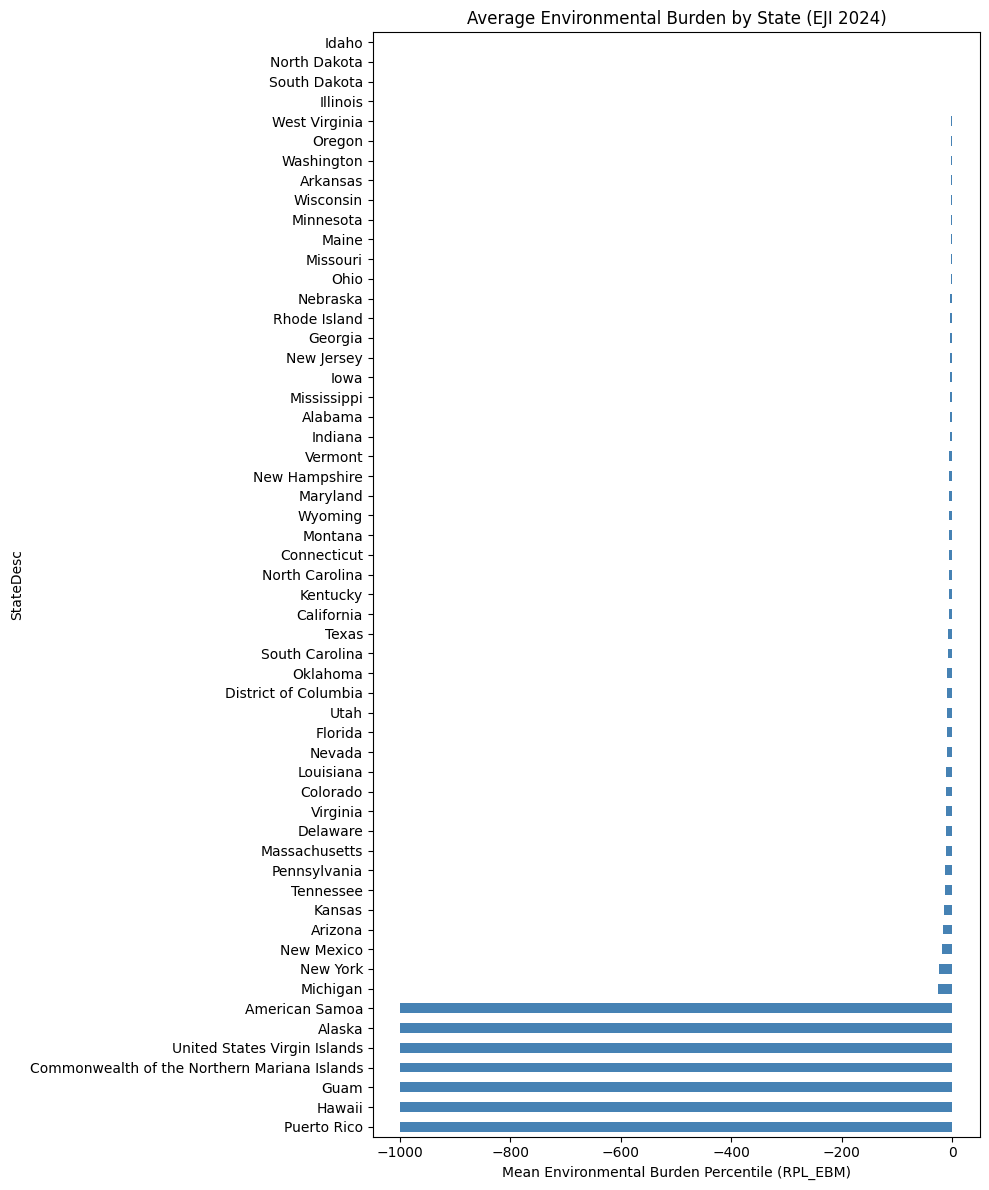

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("EJI_2024_United_States.csv")
df['RPL_EBM'] = pd.to_numeric(df['RPL_EBM'], errors='coerce')

state_ebm = df.groupby('StateDesc')['RPL_EBM'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
state_ebm.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mean Environmental Burden Percentile (RPL_EBM)')
ax.set_title('Average Environmental Burden by State (EJI 2024)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

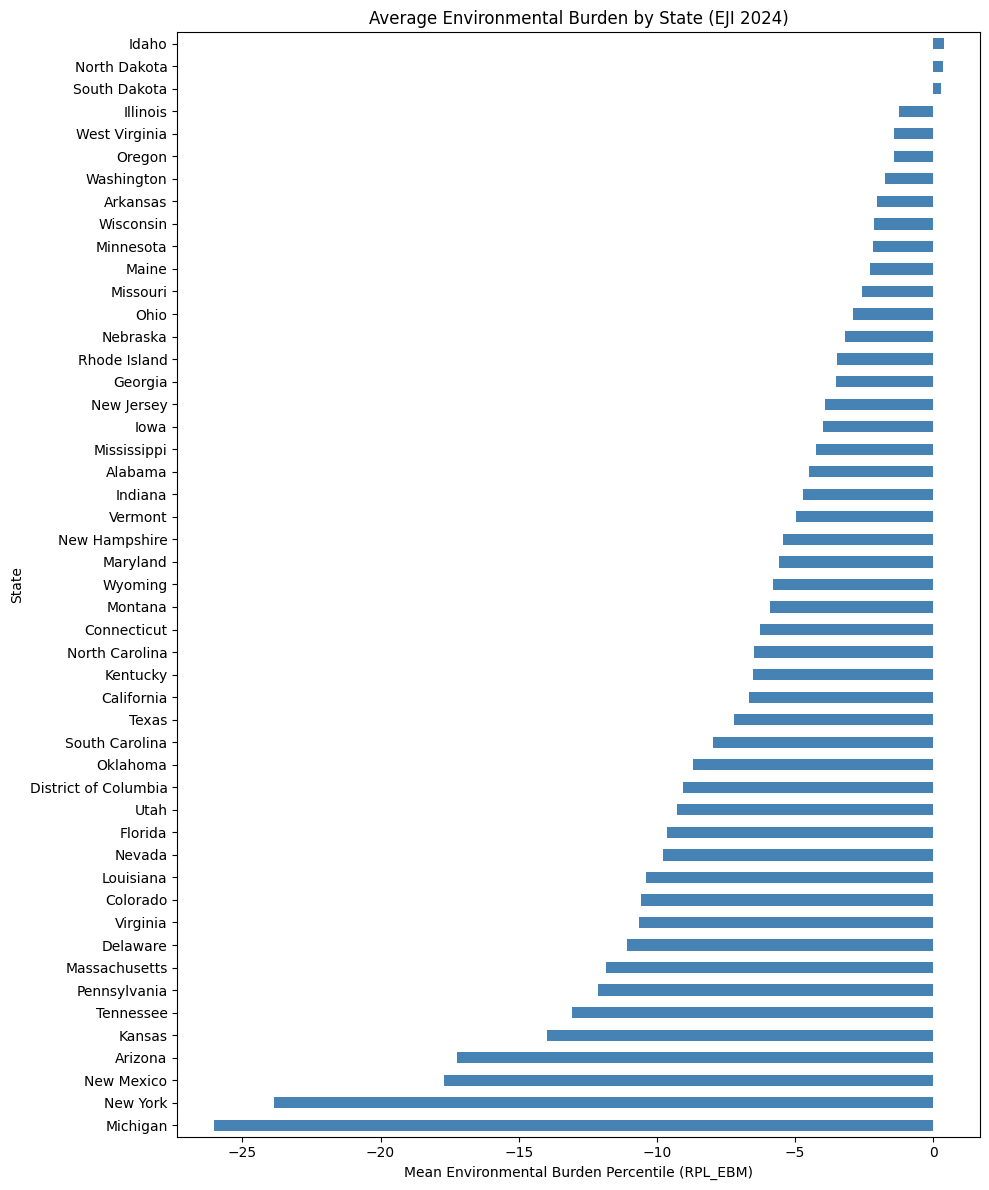

<Figure size 640x480 with 0 Axes>

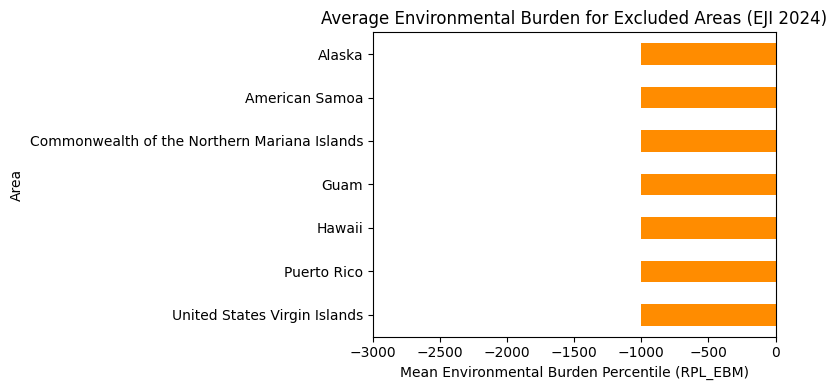

<Figure size 640x480 with 0 Axes>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("EJI_2024_United_States.csv")
df["RPL_EBM"] = pd.to_numeric(df["RPL_EBM"], errors="coerce")

special = ["American Samoa", "Alaska", "United States Virgin Islands", "Commonwealth of the Northern Mariana Islands", "Guam", "Hawaii", "Puerto Rico"]

# Main visualization: exclude the three territories
main_df = df[~df["StateDesc"].isin(special)]
state_ebm = main_df.groupby("StateDesc")["RPL_EBM"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
state_ebm.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mean Environmental Burden Percentile (RPL_EBM)")
ax.set_ylabel("State")
ax.set_title("Average Environmental Burden by State (EJI 2024)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.savefig("/Users/obedfrimpong/Desktop//qss-20-final-project/output/avg-env-burden-state.png", dpi=300, bbox_inches="tight")

# Separate visualization: only the excluded locations
special_df = df[df["StateDesc"].isin(special)]
special_ebm = special_df.groupby("StateDesc")["RPL_EBM"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
special_ebm.plot(kind="barh", ax=ax, color="darkorange") 
ax.set_xlabel("Mean Environmental Burden Percentile (RPL_EBM)")
ax.set_ylabel("Area")
ax.set_xlim(-3000, 0)
ax.set_title("Average Environmental Burden for Excluded Areas (EJI 2024)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.savefig("/Users/obedfrimpong/Desktop/qss-20-final-project/output/avg-env-burden-state-extreme.png", dpi=300, bbox_inches="tight")

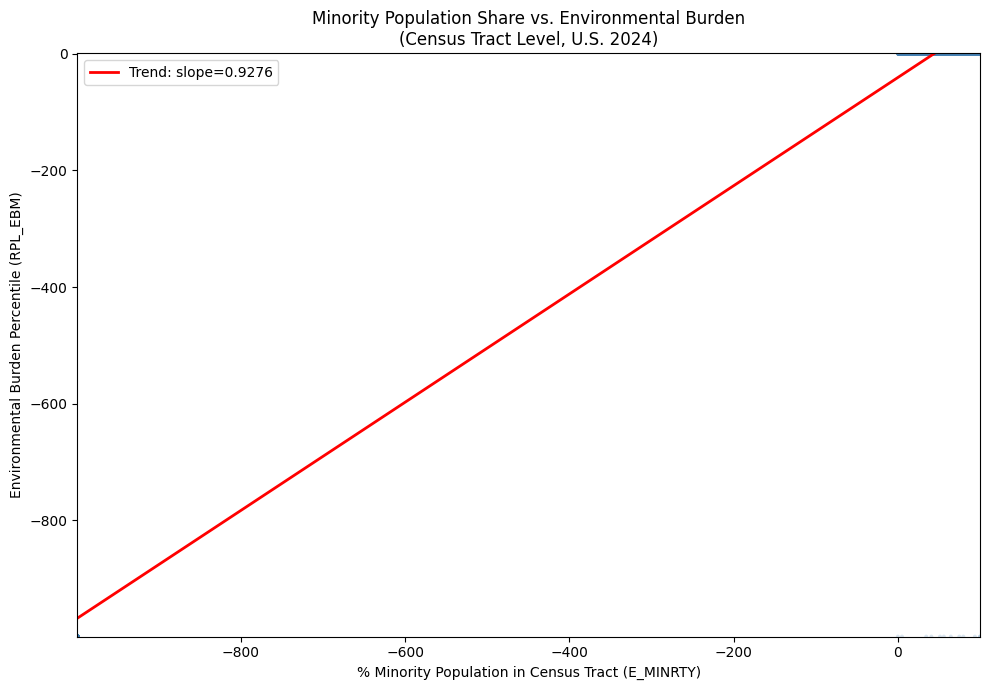

<Figure size 640x480 with 0 Axes>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

clean = df.dropna(subset=['E_MINRTY', 'RPL_EBM']).copy()

# Optional: sample for faster plotting if the dataset is very large
sample = clean.sample(n=min(5000, len(clean)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    sample['E_MINRTY'],
    sample['RPL_EBM'],
    alpha=0.2,
    s=8,
    color='steelblue',
    edgecolors='none'
)

# Trend line from the full cleaned data
z = np.polyfit(clean['E_MINRTY'], clean['RPL_EBM'], 1)
x_min, x_max = clean['E_MINRTY'].min(), clean['E_MINRTY'].max()
xs = np.linspace(x_min, x_max, 200)
ax.plot(xs, z[0] * xs + z[1], color='red', linewidth=2,
        label=f'Trend: slope={z[0]:.4f}')

ax.set_xlabel('% Minority Population in Census Tract (E_MINRTY)')
ax.set_ylabel('Environmental Burden Percentile (RPL_EBM)')
ax.set_title('Minority Population Share vs. Environmental Burden\n(Census Tract Level, U.S. 2024)')
ax.set_xlim(x_min, x_max)
ax.set_ylim(clean['RPL_EBM'].min(), clean['RPL_EBM'].max())
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("/Users/obedfrimpong/Desktop//qss-20-final-project/output/minority-pop-env-burden.png", dpi=300, bbox_inches="tight")